# **Imports**

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

from deepSTRF.datasets.video.CRCNS_PVC11_Dataset import CRCNS_PVC11_Dataset
from deepSTRF.models.video.video_zoo import SimpleConv3DModel
from deepSTRF.metrics.performance import normalized_correlation_coefficient, correlation_coefficient, signal_power

%matplotlib inline

We set device as the GPU available :

In [13]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Metal (MPS) backend:", device)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU:", device)
else:
    device = torch.device("cpu")
    print("Using CPU:", device)

Using Apple Metal (MPS) backend: mps


# **Training setup**

## Hyperparameters

In [24]:
BATCH_SIZE = 2
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_LR = 3 * LR
EPOCHS = 10

spatial_resol=(128, 128)

SIGNAL_POWER_THRESHOLD = 0.0

## Dataset loading 

In [16]:
dataset = CRCNS_PVC11_Dataset(
    path='CRCNS_PVC11',
    spatial_resol=spatial_resol,
    animal_no=(1,),
    stimuli=('natural',),
    normalize_videos=False,
    normalize_responses=False,
    response_smoothing=False,
    add_noise=False,
    temporal_resolution=10,
    split_into_clips=True,
    new_clip_len=50,
)

print("Dataset loaded successfully.")
print("Videos shape:", dataset.videos.shape)      # Expected shape (S, C, H, W, T)
print("Responses shape:", dataset.responses.shape)  # Expected shape (N, S, R, T)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

stim = natural
set contains 60 videos.
Dataset loaded successfully.
Videos shape: torch.Size([60, 1, 128, 128, 50])
Responses shape: torch.Size([69, 60, 120, 50])


We select the neurons we want to fit :

In [17]:
neuron_indices = list(range(dataset.N_neurons))
dataset.select_population(neuron_indices)
print("Selected neurons:", neuron_indices)

Selected neurons: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68]


Splitting the dataset :

In [18]:
total = len(dataset)
n_train = int(0.7 * total)
n_val = int(0.2 * total)
n_test = total - n_train - n_val

train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set size: {len(train_set)}")
print(f"Validation set size: {len(val_set)}")
print(f"Test set size: {len(test_set)}")

Train set size: 42
Validation set size: 12
Test set size: 6


## Defining the model 

In [19]:
out_neurons = dataset.responses.shape[0]  # total number of neurons
print(f'We are fitting {out_neurons} neurons')
model = SimpleConv3DModel(out_neurons=out_neurons)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total model parameters: {total_params:,}')

We are fitting 69 neurons
Total model parameters: 31,173


## Optimizer and scheduler

In [20]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    anneal_strategy='linear' 
)

# **Counting masked neurons**

In [ ]:
def count_masked_couples(dataloader, split_name):
    total_couples = 0
    total_masked = 0

    with torch.no_grad():
        for _, response, _, _ in dataloader:
            response = response.to(device)  # (B, N, R, T)
            sp = signal_power(response)     # (B, N)
            mask = (sp > SIGNAL_POWER_THRESHOLD).float()  # (B, N)

            total_couples += mask.numel()
            total_masked += (mask == 0).sum().item()

    print(f"{split_name}: {total_masked}/{total_couples} couples masked ({100.0 * total_masked / total_couples:.2f}%)")

Here we check the portion of couples (Video, Neuron) masket because of the signal power threshold :

In [25]:
model.eval()
print(f"Using signal power threshold = {SIGNAL_POWER_THRESHOLD}")
count_masked_couples(train_loader, "Train")
if len(val_loader) > 0:
    count_masked_couples(val_loader, "Validation")
count_masked_couples(test_loader, "Test")

Using signal power threshold = 0.0
Train: 1228/2898 couples masked (42.37%)
Validation: 356/828 couples masked (43.00%)
Test: 226/414 couples masked (54.59%)


# **Training loop**

In [ ]:
print(f"Using device: {device}")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_cc_total = 0.0
    train_ccnorm_total = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)
    for batch_idx, (video, response, _, _) in enumerate(pbar):
        video = video.to(device)                    # (B, C, H, W, T)
        response = response.to(device)              # (B, N, R, T)
        
        # Compute signal power per neuron for each batch item
        sp = signal_power(response)  # shape: (B, N)

        # Create a binary mask where neurons with signal power above the threshold are marked as 1
        mask = (sp > SIGNAL_POWER_THRESHOLD).float()  # shape: (B, N)
        mask = mask.to(device)  # move to the same device as model/data

        # Average across the repetition dimension (R) to get mean response per neuron over time
        target = response.mean(dim=2)  # shape: (B, N, T)

        # Apply the mask: zero out the targets of neurons with low signal power
        target = target * mask.unsqueeze(-1)  # shape: (B, N, T)

        optimizer.zero_grad()
        output = model(video)                       # (B, N, T)
        
        # Compute MSE loss per timepoint, per neuron
        loss_per_neuron = F.mse_loss(output, target, reduction='none')  # shape: (B, N, T)

        # Average loss over the time dimension, now shape is (B, N)
        loss_per_neuron = loss_per_neuron.mean(dim=-1)

        # Apply mask to exclude low-signal-power neurons from contributing to the loss
        masked_loss = loss_per_neuron * mask  # shape: (B, N)

        # Compute final loss: average over all valid (unmasked) neurons
        loss = masked_loss.sum() / (mask.sum() + 1e-8)

        loss.backward()
        optimizer.step()
        scheduler.step() 

        # Compute raw correlation coefficient per neuron
        cc = correlation_coefficient(output, target, reduction="none")  # shape: (B, N)

        # Zero out the raw response for low-signal-power neurons before passing to ccnorm
        masked_response = response * mask.unsqueeze(-1).unsqueeze(-1)  # shape: (B, N, R, T)

        # Compute normalized CC per neuron (e.g., Schoppe's method)
        ccnorm = normalized_correlation_coefficient(
            y_pred=output,
            y_gt=masked_response,
            method='schoppe',
            reduction='none'  # shape: (B, N)
        )

        # Apply mask to CC and CCnorm values to ignore invalid neurons
        masked_cc = cc * mask
        masked_ccnorm = ccnorm * mask

        # Compute mean metrics over valid (unmasked) neurons only
        total_valid = mask.sum() + 1e-8
        avg_cc = masked_cc.sum() / total_valid
        avg_ccnorm = masked_ccnorm.sum() / total_valid

        train_loss += loss.item()
        train_cc_total += avg_cc.item()
        train_ccnorm_total += avg_ccnorm.item()
        pbar.set_postfix(loss=loss.item(), cc=avg_cc.item(), ccnorm=avg_ccnorm.item())   

    train_loss /= len(train_loader)
    train_cc_avg = train_cc_total / len(train_loader)
    train_ccnorm_avg = train_ccnorm_total / len(train_loader)

    model.eval()
    val_loss, val_cc_total, val_ccnorm_total = 0.0, 0.0, 0.0
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False)
        for video, response, _, _ in pbar:
            video = video.to(device)
            response = response.to(device)          # (B, N, R, T)
            
            # Mask to get where signal power is above the threshold
            sp = signal_power(response)
            mask = (sp > SIGNAL_POWER_THRESHOLD).float()  # (B, N)
            mask = mask.to(device)
            
            target = response.mean(dim=2)  # (B, N, T)
            target = target * mask.unsqueeze(-1) 
            
            output = model(video)                       # (B, N, T)
            
            # Loss computation 
            loss_per_neuron = F.mse_loss(output, target, reduction='none')  # (B, N, T)
            loss_per_neuron = loss_per_neuron.mean(dim=-1)  # (B, N)
            masked_loss = loss_per_neuron * mask
            loss = masked_loss.sum() / (mask.sum() + 1e-8)

            # Compute raw CC and normalized CC (ccnorm)
            cc = correlation_coefficient(output, target, reduction="none")  # (B, N)
            masked_response = response * mask.unsqueeze(-1).unsqueeze(-1)
            ccnorm = normalized_correlation_coefficient(
                y_pred=output,
                y_gt=masked_response,
                method='schoppe',
                reduction='none'  # (B, N)
            )

            masked_cc = cc * mask
            masked_ccnorm = ccnorm * mask

            total_valid = mask.sum() + 1e-8  

            avg_cc = masked_cc.sum() / total_valid
            avg_ccnorm = masked_ccnorm.sum() / total_valid

            val_loss += loss.item()
            val_cc_total += avg_cc.item()
            val_ccnorm_total += avg_ccnorm.item()
            pbar.set_postfix(loss=loss.item(), cc=avg_cc.item(), ccnorm=avg_ccnorm.item())

    val_loss /= len(val_loader)
    val_cc_avg = val_cc_total / len(val_loader)
    val_ccnorm_avg = val_ccnorm_total / len(val_loader)

    print(f"[Epoch {epoch+1:02d}] "
            f"Train Loss: {train_loss:.4f} | Train CC: {train_cc_avg:.3f} | Train CCnorm: {train_ccnorm_avg:.3f} | "
            f"Val Loss: {val_loss:.4f} | Val CC: {val_cc_avg:.3f} | Val CCnorm: {val_ccnorm_avg:.3f}")
    
# ======== Final Test Evaluation ========

model.eval()
test_loss, test_cc_total, test_ccnorm_total = 0.0, 0.0, 0.0

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Test", leave=False)
    for video, response, _, _ in pbar:
        video = video.to(device)
        response = response.to(device)          # (B, N, R, T)
        
        # Mask to get where signal power is above the threshold
        sp = signal_power(response)
        mask = (sp > SIGNAL_POWER_THRESHOLD).float()  # (B, N)
        mask = mask.to(device)
        
        target = response.mean(dim=2)  # (B, N, T)
        target = target * mask.unsqueeze(-1) 
        
        output = model(video)                       # (B, N, T)
        
        # Loss computation 
        loss_per_neuron = F.mse_loss(output, target, reduction='none')  # (B, N, T)
        loss_per_neuron = loss_per_neuron.mean(dim=-1)  # (B, N)
        masked_loss = loss_per_neuron * mask
        loss = masked_loss.sum() / (mask.sum() + 1e-8)

        # Compute raw CC and normalized CC (ccnorm)
        cc = correlation_coefficient(output, target, reduction="none")  # (B, N)
        masked_response = response * mask.unsqueeze(-1).unsqueeze(-1)
        ccnorm = normalized_correlation_coefficient(
            y_pred=output,
            y_gt=masked_response,
            method='schoppe',
            reduction='none'  # (B, N)
        )

        masked_cc = cc * mask
        masked_ccnorm = ccnorm * mask

        total_valid = mask.sum() + 1e-8  

        avg_cc = masked_cc.sum() / total_valid
        avg_ccnorm = masked_ccnorm.sum() / total_valid

        test_loss += loss.item()
        test_cc_total += avg_cc.item()
        test_ccnorm_total += avg_ccnorm.item()
        pbar.set_postfix(loss=loss.item(), cc=avg_cc.item(), ccnorm=avg_ccnorm.item())
        
        

test_loss /= len(test_loader)
test_cc_avg = test_cc_total / len(test_loader)
test_ccnorm_avg = test_ccnorm_total / len(test_loader)

print(f"\n[TEST RESULTS] "
    f"Loss: {test_loss:.4f} | "
    f"CC: {test_cc_avg:.3f} | "
    f"CCnorm: {test_ccnorm_avg:.3f}")


Using device: mps


[Epoch 01] Train Loss: 0.0173 | Train CC: -0.011 | Train CCnorm: nan | Val Loss: 0.0132 | Val CC: -0.010 | Val CCnorm: nan


[Epoch 02] Train Loss: 0.0143 | Train CC: -0.001 | Train CCnorm: nan | Val Loss: 0.0137 | Val CC: 0.003 | Val CCnorm: nan


[Epoch 03] Train Loss: 0.0155 | Train CC: 0.006 | Train CCnorm: nan | Val Loss: 0.0153 | Val CC: -0.004 | Val CCnorm: nan


[Epoch 04] Train Loss: 0.0163 | Train CC: -0.009 | Train CCnorm: nan | Val Loss: 0.0141 | Val CC: -0.004 | Val CCnorm: -0.001


...

[Epoch 07] Train Loss: 0.0140 | Train CC: -0.000 | Train CCnorm: -0.000 | Val Loss: 0.0127 | Val CC: 0.002 | Val CCnorm: 0.000


[Epoch 08] Train Loss: 0.0140 | Train CC: 0.003 | Train CCnorm: 0.000 | Val Loss: 0.0128 | Val CC: -0.007 | Val CCnorm: 0.000


[Epoch 09] Train Loss: 0.0139 | Train CC: -0.005 | Train CCnorm: nan | Val Loss: 0.0120 | Val CC: -0.010 | Val CCnorm: 0.000


[Epoch 10] Train Loss: 0.0133 | Train CC: -0.002 | Train CCnorm: 0.000 | Val Loss: 0.0121 | Val CC: -0.006 | Val CCnorm: 0.000



[TEST RESULTS] Loss: 0.0082 | CC: -0.007 | CCnorm: -0.000


Plotting predictions from the test set :

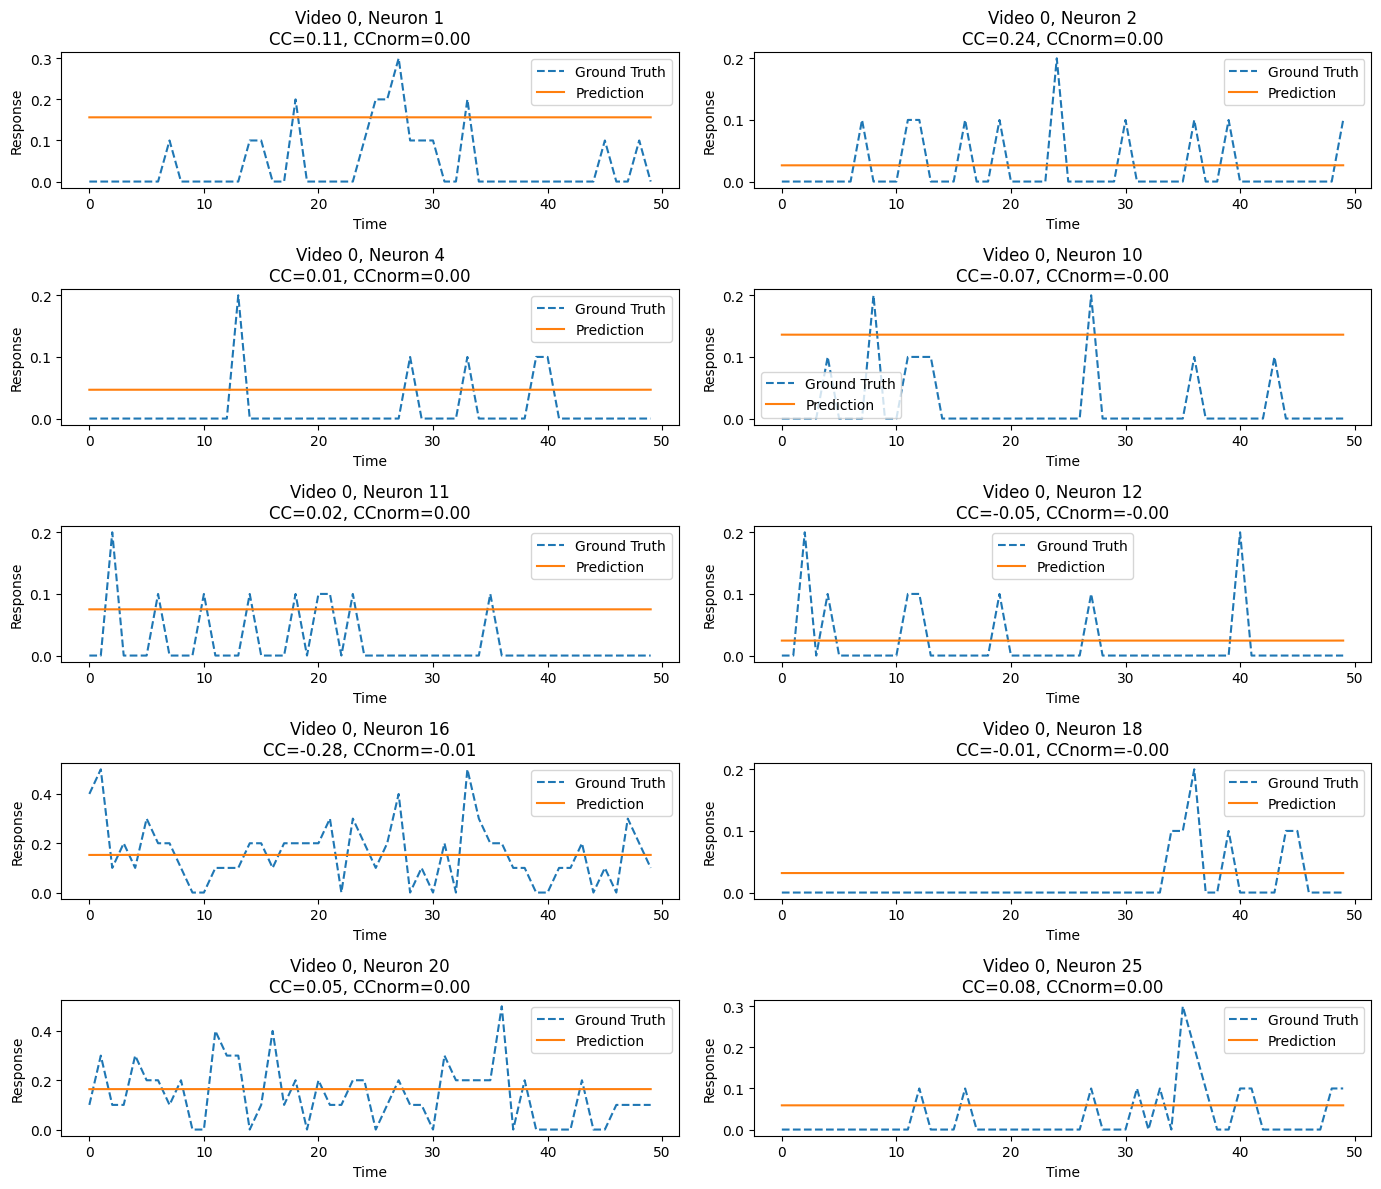

In [ ]:
number_of_couples_to_plot = 10

model.eval()
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
axes = axes.flatten()

with torch.no_grad():
    test_batch = next(iter(test_loader))
    video, response, _, _ = test_batch
    video = video.to(device)
    response = response.to(device)  # shape: (B, N, R, T)

    # Signal power and mask
    sp = signal_power(response)  # shape: (B, N)
    mask = (sp > SIGNAL_POWER_THRESHOLD).float().to(device)  # (B, N)

    target = response.mean(dim=2) * mask.unsqueeze(-1)  # (B, N, T)
    output = model(video)  # (B, N, T)
    
    # target = output

    # Compute CC and CCnorm
    raw_cc = correlation_coefficient(output, target, reduction="none")  # (B, N)
    masked_response = response * mask.unsqueeze(-1).unsqueeze(-1)       # (B, N, R, T)
    norm_cc = normalized_correlation_coefficient(
        y_pred=output,
        y_gt=masked_response,
        method='schoppe',
        reduction='none'  # (B, N)
    )

    # Apply mask
    masked_cc = raw_cc * mask
    masked_ccnorm = norm_cc * mask

    # Find indices of valid (non-masked) pairs
    valid_indices = (mask > 0).nonzero(as_tuple=False)  # shape: (K, 2), each row is [b, n]

    if len(valid_indices) < number_of_couples_to_plot:
        print(f"Only {len(valid_indices)} valid (video, neuron) pairs found.")
    selected_indices = valid_indices[:number_of_couples_to_plot]  

    for ax, (b, n) in zip(axes, selected_indices):
        pred = output[b, n].detach().cpu()
        gt = target[b, n].detach().cpu()
        cc = masked_cc[b, n].item()
        ccnorm = masked_ccnorm[b, n].item()

        ax.plot(gt, label='Ground Truth', linestyle='--')
        ax.plot(pred, label='Prediction')
        ax.set_title(f"Video {b}, Neuron {n}\nCC={cc:.2f}, CCnorm={ccnorm:.2f}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Response")
        ax.legend()

    # Turn off unused plots
    for ax in axes[len(selected_indices):]:
        ax.axis('off')

plt.tight_layout()
plt.show()